In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generate synthetic binary classification data
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features for faster convergence
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
# Build Logistic Regression Model
lr_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile Model
lr_model.compile(optimizer='adam', 
                 loss='binary_crossentropy', 
                 metrics=['accuracy'])

# Train Logistic Regression
print("Training Logistic Regression...")
lr_history = lr_model.fit(X_train, y_train, epochs=50, validation_split=0.1, verbose=0)

# Evaluate Logistic Regression
lr_loss, lr_accuracy = lr_model.evaluate(X_test, y_test, verbose=0)
print(f"Logistic Regression Test Accuracy: {lr_accuracy:.4f}")

Training Logistic Regression...
Logistic Regression Test Accuracy: 0.8300


In [3]:
# Build Deep Neural Network
dnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile Model
dnn_model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])

# Train Deep Neural Network
print("Training Deep Neural Network...")
dnn_history = dnn_model.fit(X_train, y_train, epochs=50, validation_split=0.1, verbose=0)

# Evaluate Deep Neural Network
dnn_loss, dnn_accuracy = dnn_model.evaluate(X_test, y_test, verbose=0)
print(f"DNN Test Accuracy: {dnn_accuracy:.4f}")

Training Deep Neural Network...
DNN Test Accuracy: 0.8200


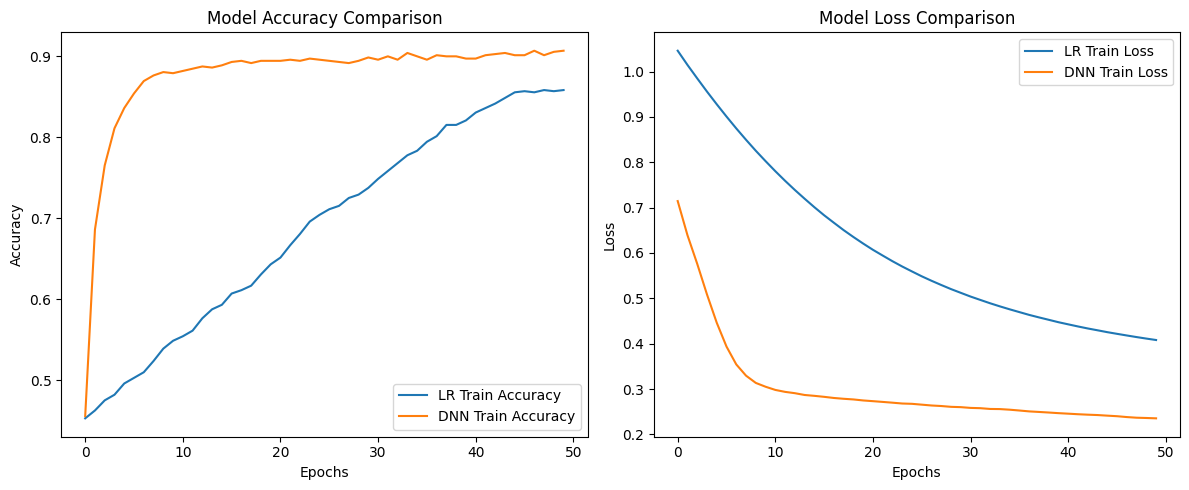

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82        89
           1       0.88      0.80      0.84       111

    accuracy                           0.83       200
   macro avg       0.83      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



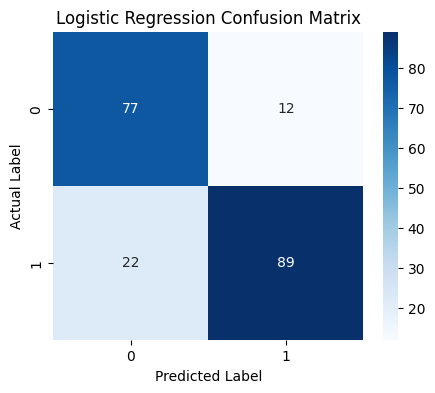

In [12]:
# Plot Training History
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(lr_history.history['accuracy'], label='LR Train Accuracy')
plt.plot(dnn_history.history['accuracy'], label='DNN Train Accuracy')
plt.title('Model Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(lr_history.history['loss'], label='LR Train Loss')
plt.plot(dnn_history.history['loss'], label='DNN Train Loss')
plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Classification Report for Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred = (lr_model.predict(X_test) > 0.5).astype("int32")
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()